In [2]:
import numpy as np 
import glob
import nibabel as nib
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import torch
from image import Image
from torch.utils.data import Dataset, DataLoader
from monai.transforms import (
    Compose, 
    ResizeWithPadOrCropd,
    EnsureChannelFirstd,
    NormalizeIntensityd,
    HistogramNormalized
)

In [3]:
## TODO
## Sanity check : all levels in axial volumes for every subject ?

In [4]:
subjects = glob.glob("../../duke/public/rsna_challenge/train_images_nii/sub-*")
int2disc = {202 : "disc_L5_S", 203: "disc_L4_L5", 204: "disc_L3_L4", 205: "disc_L2_L3", 206: "disc_L1_L2"}
int2disc.keys()
levels = [202, 203, 204, 205, 206]

In [10]:
len(subjects)
nb_axial_vol = []
for sub in tqdm(subjects):
    sub_id = sub.split("/")[-1]
    axial_vol = glob.glob(sub+"/sub*ax*.nii.gz")
    nb_axial_vol.append(len(axial_vol))

100%|██████████| 1975/1975 [00:03<00:00, 583.84it/s]


Text(0.5, 1.0, 'Histogram of number of Axial chunks in the RSNA 24 dataset')

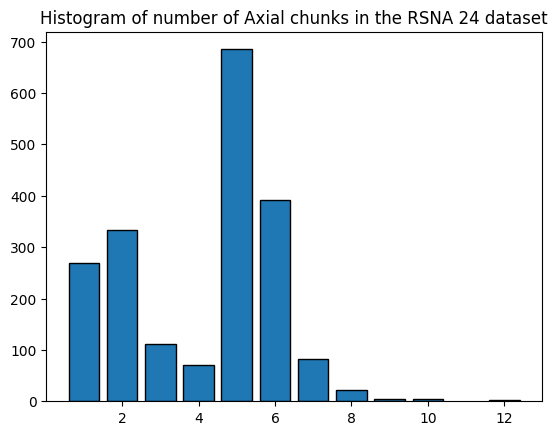

In [11]:
unique, counts = np.unique(nb_axial_vol, return_counts=True)
plt.bar(unique, counts, edgecolor="k")
plt.title("Histogram of number of Axial chunks in the RSNA 24 dataset")

In [5]:
sub_id = "sub-442325762"

In [6]:
glob.glob("../../duke/public/rsna_challenge/train_images_nii/"+sub_id+"/*T2w_i*_reg.nii.gz") 

['../../duke/public/rsna_challenge/train_images_nii/sub-442325762/sub-442325762_acq-sag_rec-2164453861_T2w_i00001_reg.nii.gz',
 '../../duke/public/rsna_challenge/train_images_nii/sub-442325762/sub-442325762_acq-sag_rec-2164453861_T2w_i00006_reg.nii.gz',
 '../../duke/public/rsna_challenge/train_images_nii/sub-442325762/sub-442325762_acq-sag_rec-2164453861_T2w_i00021_reg.nii.gz',
 '../../duke/public/rsna_challenge/train_images_nii/sub-442325762/sub-442325762_acq-sag_rec-2164453861_T2w_i00026_reg.nii.gz']

In [12]:
good_subjects =[]
bad_subjects = []
for sub in tqdm(subjects):   
    sub_id = sub.split("/")[-1]
    sub_levels = []
    segmasks = glob.glob("../../duke/public/rsna_challenge/train_images_nii/"+sub_id+"/*T2w*_reg.nii.gz") 

    for path in segmasks:
        mask = nib.load(path).get_fdata()
        nb_pixels_per_level = np.zeros(5)
        for i,  level in enumerate(levels):
            if np.sum(np.isin(mask, [level]).astype(int))>0:
                sub_levels.append(level)
                
    if len(list(set(sub_levels)))==5:
        good_subjects.append(sub_id)
    else:
        bad_subjects.append(sub_id)

100%|██████████| 1975/1975 [19:00<00:00,  1.73it/s] 


In [17]:
len(good_subjects) / len(subjects) # proportion of subjects with axial volumes for each volume

0.8121518987341773

In [18]:
# len(bad_subjects)
len(list(set(bad_subjects)))

371

In [19]:
traincsv = pd.read_csv("../data/train.csv")

In [20]:
# for sub in bad_subjects:
#     sub_id = int(sub.split("-")[-1])
#     print(traincsv[traincsv["study_id"]==sub_id].values)

In [7]:
folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036"
# folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-1095894979"
# folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-1009445512"
# folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-4646740"
# folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-4284048608"
# folder = "/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-4287160193"

In [8]:
segs = glob.glob(folder+"/*T2w*_reg.nii.gz")
vols = glob.glob(folder+"/*ax*T2w.nii.gz")

In [17]:
segs = sorted(segs, key=lambda x : x.split("_")[-2])
vols = sorted(vols, key=lambda x : x.split("_")[-2])

In [18]:
segs, vols

(['/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00001_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00006_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00012_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00018_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00023_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00024_reg.nii.gz',
  '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec

In [10]:
for seg_pth, vol_pth in zip(segs, vols):
    seg = Image(seg_pth)
    seg.change_orientation("ASL-")
    img = Image(vol_pth)
    img.change_orientation("ASL-")  
    print(img.data.shape, seg.data.shape)

(512, 5, 512) (512, 22, 512)
(512, 6, 512) (512, 6, 512)
(512, 6, 512) (512, 6, 512)
(512, 6, 512) (512, 6, 512)
(512, 6, 512) (512, 24, 512)
(512, 7, 512) (512, 6, 512)
(512, 22, 512) (512, 7, 512)


In [62]:
seg = Image(seg_pth)
seg.change_orientation("ASL-")
img = Image(vol_pth)
img.change_orientation("ASL-")

In [63]:
img.data.shape, seg.data.shape

((512, 7, 512), (512, 6, 512))

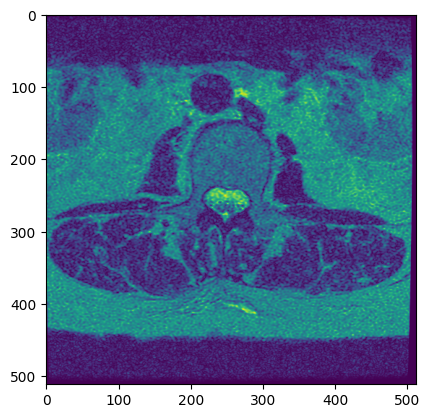

In [51]:
plt.imshow(img.data[:,-1])
plt.show()

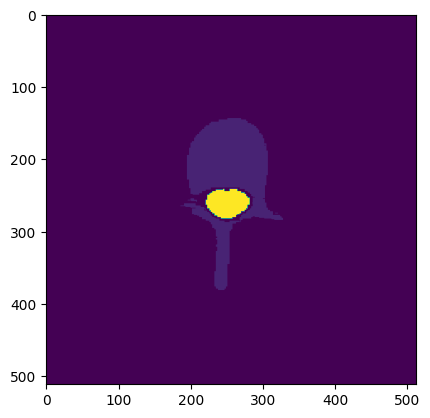

In [46]:
plt.imshow(seg.data[:,-1])
plt.show()

In [225]:
def patch_extraction(vol, mask, d=0, h=20, w=20):
    """
    Extract a ROI from a volume with a given segmentation mask.

    vol : array of shape (D, H, W)
    mask : segmentation mask of shape (D, H, W)
    d, h, w : margin for each image axis
    """
    
    D, H, W = vol.shape
    mask = torch.Tensor(mask.copy())
    nonzero_indices = torch.nonzero(mask)  # Extracting non-zero indices from the first channel

    d_min, h_min, w_min = nonzero_indices.min(0)[0]  # Minimum indices
    d_max, h_max, w_max = nonzero_indices.max(0)[0]  # Maximum indices
    
    patch = vol[max(0, d_min-d):min(D, d_max + d), 
                max(0, h_min - h):min(H, h_max + h), 
                max(0, w_min - w):min(W, w_max + w)]

    return patch

In [226]:
mask = np.isin(img.data, [202])

In [227]:
patch = patch_extraction(img2.data, mask, d=300, h=0, w=300)

In [228]:
patch.shape

(272, 3, 272)

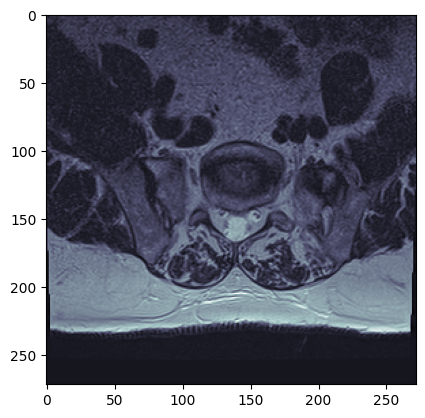

In [231]:
plt.imshow(patch[:,-1], cmap="bone")
plt.show()

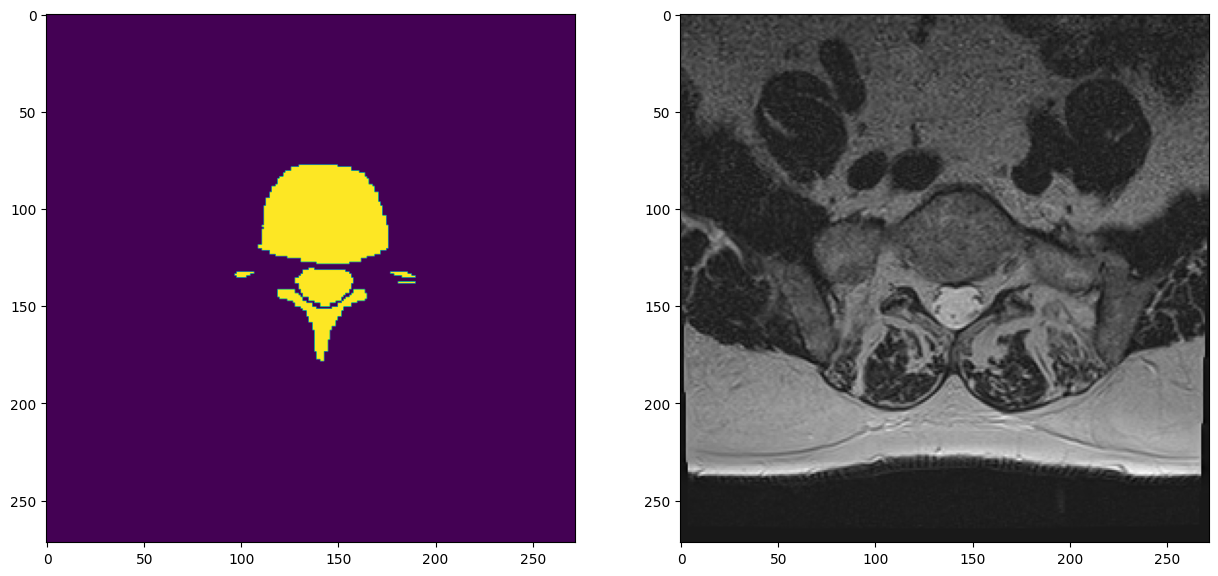

In [234]:
fig, ax = plt.subplots(ncols=2, figsize=(15, 10))
ax[0].imshow(img.data[:,0,:]>0)
ax[1].imshow(patch[:,0], cmap="gray")
plt.show()

In [ ]:
## TODO : patch extraction

In [61]:
segs[0], vols[0]

('/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-sag_rec-3491739931_T2w_i00001_reg.nii.gz',
 '/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/sub-10728036/sub-10728036_acq-ax_rec-1376017717_i00001_T2w.nii.gz')

In [57]:
vol, seg = vols[0], segs[0]

In [59]:
vol_img = Image(vol).data
seg_img = Image(seg).data

In [60]:
vol_img.shape, seg_img.shape

((512, 512, 5), (512, 512, 22))

In [33]:
for path in segmasks:
    mask = nib.load(path).get_fdata()
    print(np.unique(mask))
    # nb_pixels = np.zeros(5)
    # for i, level in enumerate(levels):
        

[  0.  20.  21.  22.  23. 200. 201. 205. 206. 207.]
[  0.  21.  22. 200. 201. 206.]
[  0.  20.  21. 201. 205.]
[  0.  19.  20. 201. 204.]
[  0.  18.  19.  20.  92. 201. 202. 203. 204.]
[  0.  18.  19. 201. 203.]
[  0.  18.  19.  92. 201. 202.]


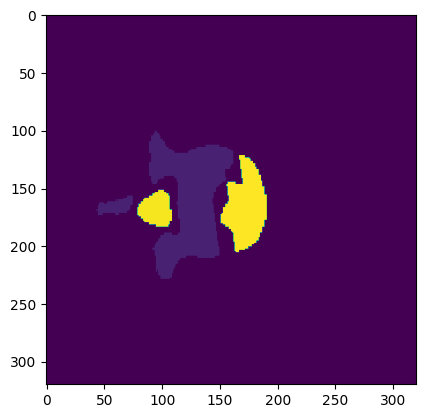

In [ ]:
plt.imshow(mask[:,:,2])

In [36]:
for path in segmasks:
    mask = nib.load(path).get_fdata()
    # print(np.unique(mask))
    nb_pixels = np.zeros(5)
    for i, level in enumerate(levels):
        nb_pixels[i] = np.sum(np.isin(mask, [level]).astype(int))
    
    nb_pixels /= nb_pixels.sum()
    print(nb_pixels)
    print(int2disc[levels[np.argmax(nb_pixels)]])

[0.         0.         0.         0.50898957 0.49101043]
disc_L2_L3
[0. 0. 0. 0. 1.]
disc_L1_L2
[0. 0. 0. 1. 0.]
disc_L2_L3
[0. 0. 1. 0. 0.]
disc_L3_L4
[0.35514032 0.31819585 0.32666382 0.         0.        ]
disc_L5_S
[0. 1. 0. 0. 0.]
disc_L4_L5
[1. 0. 0. 0. 0.]
disc_L5_S


In [46]:
# seg = glob.glob("/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/*/*T2w*i0*_reg.nii.gz")
# vol = glob.glob("/home/ge.polymtl.ca/p120616/duke/public/rsna_challenge/train_images_nii/*/*i0*T2w.nii.gz")

In [49]:
len(vol), len(seg)

(7336, 7173)

In [ ]:
good_subjects

In [ ]:
class SubarticularStenosisDataset(Dataset):
    def __init__(self, 
                 root_dir : str = "../../TotalSpineSeg",
                 vol_paths : list = None,
                 seg_paths : list = None,
                 labels_csv : str = "../data/train.csv",
                 transform : any = None):
        
        
        text2int = {"Normal/Mild": 0, "Moderate": 1, "Severe": 2}
        vol_paths.sort()
        seg_paths.sort()
        self.vol_paths = vol_paths
        self.seg_paths = seg_paths
        self.transform = transform
        self.root_dir = root_dir
        
        self.labels = pd.read_csv(labels_csv)
        self.labels = self.labels[["study_id",
                                   "right_subarticular_stenosis_l1_l2",
                                   "right_subarticular_stenosis_l2_l3",
                                   "right_subarticular_stenosis_l3_l4",
                                   "right_subarticular_stenosis_l4_l5",
                                   "right_subarticular_stenosis_l5_s1",
                                   "left_subarticular_stenosis_l1_l2",
                                   "left_subarticular_stenosis_l2_l3",
                                   "left_subarticular_stenosis_l3_l4",
                                   "left_subarticular_stenosis_l4_l5",
                                   "left_subarticular_stenosis_l5_s1"]]
        self.labels = self.labels.replace(text2int)
        
    def __len__(self):
        return len(self.vol_paths)
        
    def __getitem__(self, idx):
        
        vol_path = self.vol_paths[idx]
        x = vol_path.split("/")[-1]
        x = x[:-7]+"_0000.nii.gz"
        
        
        study_id = x.split("_")[0][4:]
        
        seg_path = self.seg_paths[idx]
        
        label = self.labels[self.labels["study_id"]==int(study_id)].values[0,1:].astype(int)
        
        vol = Image(path+"/output/input/"+x)
        vol.change_orientation("LSA")
        vol = vol.data
        seg = Image(seg_path)
        seg.change_orientation("LSA")
        seg = seg.data
        
        D, H, W = vol.shape
        discs = np.isin(seg, [202, 203, 204, 205, 206]).astype(int)
        disc_l5 = np.isin(seg, [202]).astype(int)
        disc_l4 = np.isin(seg, [203]).astype(int)
        disc_l3 = np.isin(seg, [204]).astype(int)
        disc_l2 = np.isin(seg, [205]).astype(int)
        disc_l1 = np.isin(seg, [206]).astype(int)
        spinal_canal = np.isin(seg, [201]).astype(int)

        discs = [disc_l1, disc_l2, disc_l3, disc_l4, disc_l5]
        levels = ["L1/L2", "L2/L3", "L3/L4", "L4/L5", "L5/S1"]
        patches = {}
        patches_seg = {}
        
        for i, disc in enumerate(discs):
            patch = patch_extraction(vol, disc, d=0, h=20, w=20).copy()
            patch_seg = patch_extraction(spinal_canal, disc, d=0, h=20, w=20).copy()
            patches[levels[i]] = torch.Tensor(patch[None])
            patches_seg[levels[i]] = torch.Tensor(patch_seg[None])
                
        if self.transform is not None:
            patches = self.transform(patches)
            patches_seg = self.transform(patches_seg)
        
        return patches, patches_seg, label       